In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.sample(5)

,Survived,Age,Fare
825,0,NaN,6.9500
707,1,42.0,26.2875
552,0,NaN,7.8292
388,0,NaN,7.7292
97,1,23.0,63.3583


# **c. Random Value Imputation**

Fills each missing value with a value **randomly sampled from the existing (non-missing) distribution** of that same column.

- Preserves the original variance/distribution shape better than mean/median imputation, since you're not collapsing everything to a single point.
- Introduces randomness, so results can vary between runs (should set a random seed for reproducibility).
- Is applicable on both numerical and categorical data.

# Numerical Data:

In [3]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [4]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [7]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (X_train['Age'].dropna().sample(X_train['Age'].isnull().sum(),random_state=42).values)
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (X_test['Age'].dropna().sample(X_test['Age'].isnull().sum(),random_state=42).values)

In [8]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,18.0
493,71.0,49.5042,71.0
527,NaN,221.7792,21.0


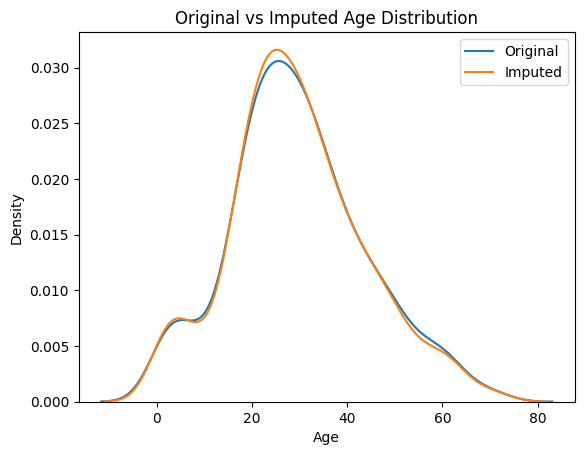

In [9]:
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')
plt.legend()
plt.xlabel('Age')
plt.title('Original vs Imputed Age Distribution')
plt.show()

In [10]:
print('Original Age column variance: ',X_train['Age'].var())
print('Age column variance after end of distribution Imputation: ',X_train['Age_imputed'].var())

Original Age column variance:  204.34951339046142
Age column variance after end of distribution Imputation:  200.02896637747122


In [11]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.259863
Age,71.512440,204.349513,204.349513
Age_imputed,53.259863,204.349513,200.028966


<Axes: >

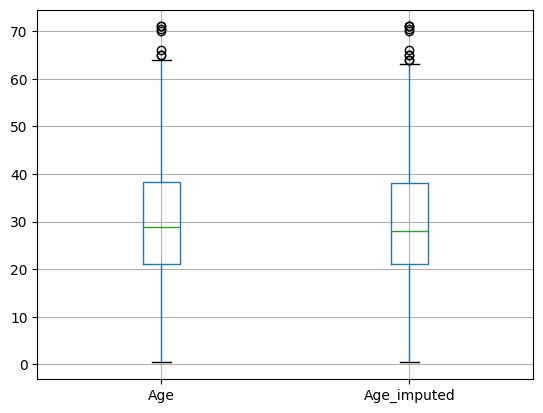

In [12]:
X_train[['Age','Age_imputed']].boxplot()

# Categorical Data:

In [13]:
data = pd.read_csv('housing_dataset.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
data.sample(5)

,FireplaceQu,GarageQual,SalePrice
379,TA,TA,179000
232,Po,TA,94500
928,TA,TA,236500
99,NaN,NaN,128950
443,Gd,TA,172500


In [14]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [15]:
X_new = data
y_new = data['SalePrice']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_new,y_new,test_size=0.2,random_state=2)

In [17]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [18]:
X_train.head()

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd


In [19]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (X_train['GarageQual'].dropna().sample(
    X_train['GarageQual'].isnull().sum(),random_state=42).values)
X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (X_test['GarageQual'].dropna().sample(
    X_test['GarageQual'].isnull().sum(),random_state=42).values)

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (X_train['FireplaceQu'].dropna().sample(
    X_train['FireplaceQu'].isnull().sum(),random_state=42).values)
X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (X_test['FireplaceQu'].dropna().sample(
    X_test['FireplaceQu'].isnull().sum(),random_state=42).values)

In [25]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ], axis=1)

temp.columns = ['Orignal','Imputed']

In [26]:
temp*100

,Orignal,Imputed
TA,95.104261,95.205479
Fa,3.717135,3.681507
Gd,0.997280,0.941781
Po,0.090662,0.085616
Ex,0.090662,0.085616


In [27]:
temp2 = pd.concat(
    [
        X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
        X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
    ], axis=1)

temp2.columns = ['Orignal','Imputed']

In [28]:
temp2*100

,Orignal,Imputed
Gd,49.427169,50.000000
TA,41.243863,40.667808
Fa,4.091653,4.023973
Po,2.782324,2.825342
Ex,2.454992,2.482877


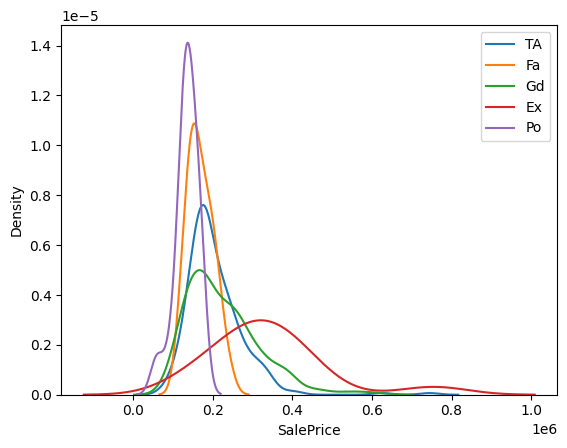

In [30]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
    plt.legend()

plt.show()